# Breast Cancer Subtype Classification
### EfficientNet-B0 Fine-tuning Pipeline

This notebook trains an EfficientNet-B0 model to classify 8 breast tumor subtypes:
- Benign: Adenosis (A), Fibroadenoma (F), Phyllodes Tumor (PT), Tubular Adenoma (TA)
- Malignant: Ductal Carcinoma (DC), Lobular Carcinoma (LC), Mucinous Carcinoma (MC), Papillary Carcinoma (PC)

I choose EfficientNet-B0 because of, it does exceptional job on rather small datasets. Its smaller than other competitors like ResNet50 or VGG16 so i could try and experiment more. If more accuracy needed i could go for higher Efficient-Net models like B4 B7 or else.

Some observations about dataset:
- Malignant samples outnumber benign by roughly 2.2:1. \
    So a good augmentation needed
- The four zoom levels (40×–400×) produce visually distinct image textures.
- Multiple images per patient means naive random splits can leak patient data across train/validation sets. \
    We need a solution for that.
- Each filename encodes the biopsy type, tumor type, patient ID, and magnification.

Variables and Setup

In [1]:
import copy
import time
import torch
import os
import re
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

Set to one of: 400, 200, 100, 40 or None to keep all magnifications.
Using a single magnification eliminates the data leakage where
the same tissue region appears at 40×, 100×, 200×, and 400×. We could gone for a more complex splitting algorithm but this one does its job.

In [2]:
data_dir      = globals().get("data_dir",      "breast")
batch_size    = globals().get("batch_size",    32)
num_epochs    = 100
lr            = globals().get("lr",            1e-3)
val_ratio     = globals().get("val_ratio",     0.3)
num_workers   = globals().get("num_workers",   0)

# ── Leakage-fix knob ──────────────────────────────────────────────────────────
# Set to one of: 400, 200, 100, 40  — or None to keep all magnifications.
# Using a single magnification eliminates the data leakage where
# the same tissue region appears at 40×, 100×, 200×, and 400×.
MAGNIFICATION_FILTER = globals().get("MAGNIFICATION_FILTER", 40)
# ─────────────────────────────────────────────────────────────────────────────

ORIGINAL_IMAGEFOLDER = datasets.ImageFolder


We extract our data with a helper class with helper methods.


In [3]:
class BreastSubtypeDataset(Dataset):
    """
    Custom Dataset class that:
      1. Parses BreaKHis filenames to infer the 8 tumor subtypes.
      2. Optionally filters to a single magnification level to avoid
         data leakage.
    """
    def __init__(self, root, transform=None, magnification_filter=None):
        self.root = root
        self.transform = transform
        self._fallback_dataset = None

        self.classes      = ["A", "F", "PT", "TA", "DC", "LC", "MC", "PC"]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = []   # list of (path, label_int)
        self.targets      = []

        aliases = {
            "ADENOSIS": "A", "A": "A",
            "FIBROADENOMA": "F", "F": "F",
            "PHYLLODES": "PT", "PT": "PT",
            "TUBULARADENOMA": "TA", "TUBULAR": "TA", "TA": "TA",
            "DUCTALCARCINOMA": "DC", "DUCTAL": "DC", "DC": "DC",
            "LOBULARCARCINOMA": "LC", "LOBULAR": "LC", "LC": "LC",
            "MUCINOUSCARCINOMA": "MC", "MUCINOUS": "MC", "MC": "MC",
            "PAPILLARYCARCINOMA": "PC", "PAPILLARY": "PC", "PC": "PC",
        }

        def infer_tumor_type(path, fname):
            stem = os.path.splitext(fname)[0]
            tokens     = [t.upper() for t in re.split(r"[_\-\s]+", stem) if t]
            dir_tokens = [t.upper() for t in re.split(r"[_\-\s]+",
                          os.path.basename(os.path.dirname(path))) if t]
            all_tokens = tokens + dir_tokens
            for t in all_tokens:
                if t in self.class_to_idx: return t
            for t in all_tokens:
                if t in aliases: return aliases[t]
            parts = fname.split("_")
            if len(parts) >= 3:
                t = parts[2].upper()
                if t in self.class_to_idx: return t
                if t in aliases:           return aliases[t]
            return None

        valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if not fname.lower().endswith(valid_ext):
                    continue
                path = os.path.join(dirpath, fname)
                tumor_type = infer_tumor_type(path, fname)
                if tumor_type is None:
                    continue

                # ── Magnification filter ──────────────────────────────────────
                if magnification_filter is not None:
                    stem = os.path.splitext(fname)[0]
                    parts = stem.split("-")
                    try:
                        mag = int(parts[-2])  # second-to-last token is magnification
                    except (ValueError, IndexError):
                        mag = None
                    if mag != magnification_filter:
                        continue
                # ─────────────────────────────────────────────────────────────

                target = self.class_to_idx[tumor_type]
                self.samples.append((path, target))
                self.targets.append(target)

        self.imgs = self.samples

        if len(self.samples) == 0:
            folder_ds = ORIGINAL_IMAGEFOLDER(root=root, transform=transform)
            if len(folder_ds) == 0:
                raise RuntimeError(f"No valid images found in '{root}'.")
            self._fallback_dataset = folder_ds
            self.samples   = folder_ds.samples
            self.targets   = [y for _, y in folder_ds.samples]
            self.classes   = folder_ds.classes
            self.class_to_idx = folder_ds.class_to_idx
            self.imgs = self.samples
            print("Warning: subtype labels not found in filenames; using folder labels via ImageFolder.")

    def __len__(self):
        if self._fallback_dataset is not None:
            return len(self._fallback_dataset)
        return len(self.samples)

    def __getitem__(self, index):
        if self._fallback_dataset is not None:
            return self._fallback_dataset[index]
        path, target = self.samples[index]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, target


datasets.ImageFolder = BreastSubtypeDataset


Hardware setup etc.

In [4]:
# Setup hardware accelerator: Use Nvidia GPU if available, otherwise fall back to CPU processing
device = globals().get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
weights = globals().get("weights", EfficientNet_B0_Weights.DEFAULT)

preset = weights.transforms()
mean = getattr(preset, "mean", (0.485, 0.456, 0.406))
std = getattr(preset, "std", (0.229, 0.224, 0.225))

Augmentations

In [5]:
# Training transforms include heavy augmentation to prevent overfitting
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Randomly zoom and crop to 224x224 (EfficientNet default)
    transforms.RandomHorizontalFlip(),                   # 50% chance to flip left-right
    transforms.RandomVerticalFlip(),                     # 50% chance to flip up-down
    transforms.RandomRotation(15),                       # Rotate image between -15 and 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05), # Randomly tweak colors slightly
    transforms.ToTensor(),                               # Convert PIL Image (0-255) to PyTorch Tensor (0.0-1.0)
    transforms.Normalize(mean=mean, std=std),            # Apply the extracted ImageNet normalization constants
])

# Validation transforms only resize and normalize (no random augmentations)
# We need to evaluate the model on standard, undistorted images
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

Straitified Random split. 

In [6]:
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

# ── 1. Load the full dataset (magnification already filtered inside the class) ──
full_dataset = BreastSubtypeDataset(
    root=data_dir,
    transform=train_transform,
    magnification_filter=MAGNIFICATION_FILTER,
)
num_classes = len(full_dataset.classes)

print(f"Total samples after mag filter ({MAGNIFICATION_FILTER}\u00d7): {len(full_dataset)}")
print(f"Classes ({num_classes}): {full_dataset.classes}")

y = np.array(full_dataset.targets)
indices = np.arange(len(full_dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=val_ratio,
    stratify=y,
    random_state=42,
)

print(f"Samples — train: {len(train_indices)}, val: {len(val_indices)}")
print(f"Val ratio achieved: {len(val_indices)/len(full_dataset):.3f}")


train_dataset = Subset(full_dataset, train_indices)

val_base = BreastSubtypeDataset(
    root=data_dir,
    transform=val_transform,
    magnification_filter=MAGNIFICATION_FILTER,
)
val_dataset = Subset(val_base, val_indices)

# ── 4. DataLoaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Device: {device}")


Total samples after mag filter (40×): 1995
Classes (8): ['A', 'F', 'PT', 'TA', 'DC', 'LC', 'MC', 'PC']
Samples — train: 1396, val: 599
Val ratio achieved: 0.300
Device: cuda


In [33]:
import pandas as pd
from IPython.display import display

# Use existing notebook objects if available; otherwise build a lightweight dataset
dataset = globals().get("full_dataset")
if dataset is None:
    dataset = BreastSubtypeDataset(
        root=data_dir,
        transform=None,
        magnification_filter=globals().get("MAGNIFICATION_FILTER", None),
    )

class_counts = Counter(dataset.targets)
class_names = list(dataset.classes)
total_samples = len(dataset)

# Overall metadata table
dataset_meta = pd.DataFrame(
    [
        ["Total samples", total_samples],
        ["Num classes", len(class_names)],
        ["Magnification filter", globals().get("MAGNIFICATION_FILTER", None)],
        ["Data directory", data_dir],
    ],
    columns=["Field", "Value"],
)

# Class distribution table
class_meta = pd.DataFrame(
    [
        {
            "Class": cls,
            "Count": class_counts.get(i, 0),
            "Percent": round(100 * class_counts.get(i, 0) / total_samples, 2) if total_samples else 0.0,
        }
        for i, cls in enumerate(class_names)
    ]
)

display(dataset_meta)
display(class_meta)

# Optional split metadata if train/val indices already exist
if "train_indices" in globals() and "val_indices" in globals():
    split_meta = pd.DataFrame(
        [
            ["Train samples", len(train_indices)],
            ["Val samples", len(val_indices)],
            ["Train ratio", round(len(train_indices) / total_samples, 3)],
            ["Val ratio", round(len(val_indices) / total_samples, 3)],
        ],
        columns=["Field", "Value"],
    )

    train_counts = Counter(np.array(dataset.targets)[train_indices])
    val_counts = Counter(np.array(dataset.targets)[val_indices])

    split_class_meta = pd.DataFrame(
        [
            {
                "Class": cls,
                "Train": train_counts.get(i, 0),
                "Val": val_counts.get(i, 0),
                "Total": class_counts.get(i, 0),
            }
            for i, cls in enumerate(class_names)
        ]
    )

    display(split_meta)
    display(split_class_meta)

,Field,Value
0,Total samples,1995
1,Num classes,8
2,Magnification filter,40
3,Data directory,breast


,Class,Count,Percent
0,A,114,5.71
1,F,253,12.68
2,PT,109,5.46
3,TA,149,7.47
4,DC,864,43.31
5,LC,156,7.82
6,MC,205,10.28
7,PC,145,7.27


,Field,Value
0,Train samples,1396.0
1,Val samples,599.0
2,Train ratio,0.7
3,Val ratio,0.3


,Class,Train,Val,Total
0,A,80,34,114
1,F,177,76,253
2,PT,76,33,109
3,TA,104,45,149
4,DC,605,259,864
5,LC,109,47,156
6,MC,143,62,205
7,PC,102,43,145


Dataset is imbalanced. We calculate inverse frequency weights so the loss function penalizes errors on rare classes more heavily.

In [7]:
cnt = Counter(full_dataset.targets)
print("Class counts:", {full_dataset.classes[k]: v for k, v in sorted(cnt.items())})

total_samples = sum(cnt.values())
# Formula: Weight = Total / (Num_Classes * Count_of_Class) 
# Frequent classes get a weight < 1, rare classes get a weight > 1
class_weights = [total_samples / (num_classes * cnt[i]) for i in range(num_classes)]
# Move the weights tensor to the GPU/CPU so the loss function can access it
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

Class counts: {'A': 114, 'F': 253, 'PT': 109, 'TA': 149, 'DC': 864, 'LC': 156, 'MC': 205, 'PC': 145}


Model Setup

In [8]:
# Initialize the EfficientNet model and load the pre-trained weights
model = models.efficientnet_b0(weights=weights)

# Freeze the entire network initially to preserve pre-trained feature extractors
# setting requires_grad = False freezes the layers
for p in model.parameters():
    p.requires_grad = False

# Unfreeze the later stages of the network. This allows the model to learn 
# dataset-specific high-level features while keeping low-level edge/texture detectors frozen.
# model.features[5:] accesses the deeper residual blocks of the EfficientNet architecture.
for p in model.features[7:].parameters():
    p.requires_grad = True

# Replace the final classification head to match our 8 target classes instead of ImageNet's 1000
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

Optimization & Learning Rate Scheduler

In [9]:
# Pass the class weights to the loss function to handle the dataset imbalance
# CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss() in one single class
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam([
    {'params': model.features[7:].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': lr}
])

# Reduces the learning rate by half if validation loss stops improving for 3 epochs
# This helps the model "settle" into a local minimum when it plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
start = time.time()

Training Loop

In [10]:
patience = 15
epochs_no_improve = 0

# Dictionaries to store metrics for plotting later
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

for epoch in range(num_epochs):
    # Set model to training mode (enables dynamic behaviors like dropout and batchnorm updates)
    model.train() 
    train_loss, train_correct, train_total = 0.0, 0, 0

    # Iterate over batches of images and labels from the training DataLoader
    for bi, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device) # Move data to the same device as the model
        
        optimizer.zero_grad()      # Clear old gradients from the previous step so they don't accumulate
        logits = model(x)          # Forward pass: pass inputs through the network to get raw output scores
        loss = criterion(logits, y)# Compute loss: compare raw scores to actual true labels
        loss.backward()            # Backward pass: compute gradients of the loss w.r.t model parameters
        optimizer.step()           # Update weights: adjust parameters based on calculated gradients

        # Accumulate metrics: loss.item() gets the scalar value, multiply by batch size to un-average it
        train_loss += loss.item() * x.size(0)
        # argmax(1) finds the index of the highest logit score (the predicted class)
        train_correct += (logits.argmax(1) == y).sum().item()
        train_total += y.size(0)

        # Print early feedback during the first epoch
        if epoch == 0 and bi % 20 == 0:
            print(f"[epoch 1] batch {bi}/{len(train_loader)} loss={loss.item():.4f}")

    # Set model to evaluation mode (disables dropout, freezes batchnorm statistics for consistent testing)
    model.eval() 
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    # torch.no_grad() disables gradient calculation to save memory and compute time during inference
    with torch.no_grad(): 
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            # Accumulate validation metrics
            val_loss += loss.item() * x.size(0)
            val_correct += (logits.argmax(1) == y).sum().item()
            val_total += y.size(0)

    # Calculate average metrics for the epoch by dividing total accumulated values by dataset size
    tr_loss = train_loss / train_total
    tr_acc = train_correct / train_total
    va_loss = val_loss / val_total
    va_acc = val_correct / val_total
    
    # Save metrics to our history dictionary for plotting
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    scheduler.step(va_loss)

    # Check for improvement and save the best model weights into memory
    if va_acc > best_acc:
        best_acc = va_acc
        # deepcopy ensures we save a distinct copy of the weights, not just a reference
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        # Increment counter if validation accuracy didn't improve
        epochs_no_improve += 1

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
        f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f}"
    )

    # Halt training if the model hasn't improved in 'patience' epochs to save time and prevent overfitting
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered! Validation accuracy hasn't improved for {patience} epochs.")
        break

[epoch 1] batch 0/44 loss=2.0179
[epoch 1] batch 20/44 loss=1.9385
[epoch 1] batch 40/44 loss=1.6498
Epoch [1/100] Train Loss: 1.8469 Acc: 0.3517 | Val Loss: 1.5428 Acc: 0.5309
Epoch [2/100] Train Loss: 1.4397 Acc: 0.4928 | Val Loss: 1.2894 Acc: 0.5292
Epoch [3/100] Train Loss: 1.2039 Acc: 0.5638 | Val Loss: 1.1438 Acc: 0.5860
Epoch [4/100] Train Loss: 1.0968 Acc: 0.6089 | Val Loss: 1.0424 Acc: 0.6244
Epoch [5/100] Train Loss: 1.0296 Acc: 0.6196 | Val Loss: 0.9575 Acc: 0.6294
Epoch [6/100] Train Loss: 0.9374 Acc: 0.6411 | Val Loss: 0.8766 Acc: 0.6611
Epoch [7/100] Train Loss: 0.8901 Acc: 0.6418 | Val Loss: 0.8592 Acc: 0.6544
Epoch [8/100] Train Loss: 0.8346 Acc: 0.6655 | Val Loss: 0.8052 Acc: 0.6778
Epoch [9/100] Train Loss: 0.8163 Acc: 0.6712 | Val Loss: 0.7779 Acc: 0.6628
Epoch [10/100] Train Loss: 0.7695 Acc: 0.6984 | Val Loss: 0.7418 Acc: 0.7012
Epoch [11/100] Train Loss: 0.7509 Acc: 0.7063 | Val Loss: 0.7343 Acc: 0.6878
Epoch [12/100] Train Loss: 0.7202 Acc: 0.7013 | Val Loss: 0.6

Save Best Model Checkpoint

In [11]:
# Load the best weights back into the model before saving it to disk
model.load_state_dict(best_state)
# Save a dictionary (checkpoint) containing the weights, class names, and performance
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": full_dataset.classes,
        "best_val_acc": best_acc,
    },
    "efficientnet_b0_breast_best.pth",
)

print(f"Training done in {(time.time() - start)/60:.1f} min. Best val acc: {best_acc:.4f}")

Training done in 69.0 min. Best val acc: 0.8531


Visualization: Loss & Accuracy Curves

Plot Loss and Accuracy Curves to visually check for overfitting (train and val diverging) or underfitting.

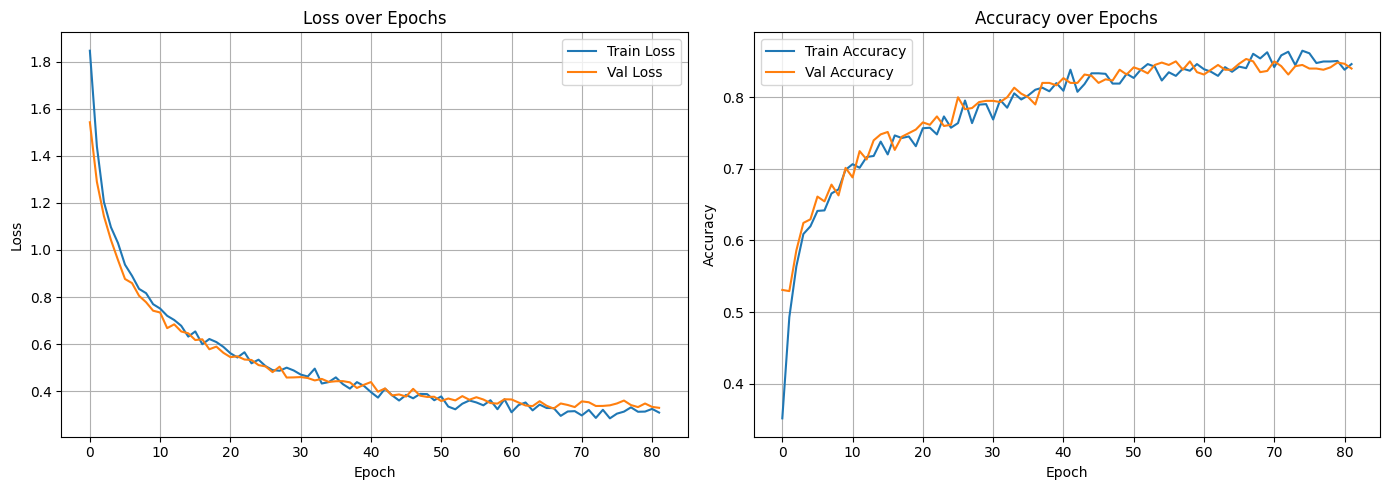

In [12]:
plt.figure(figsize=(14, 5))

# Subplot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Visualization: Confusion Matrix

Generate Confusion Matrix to see which specific classes are being misclassified as others.

Generating Confusion Matrix on Validation Set...


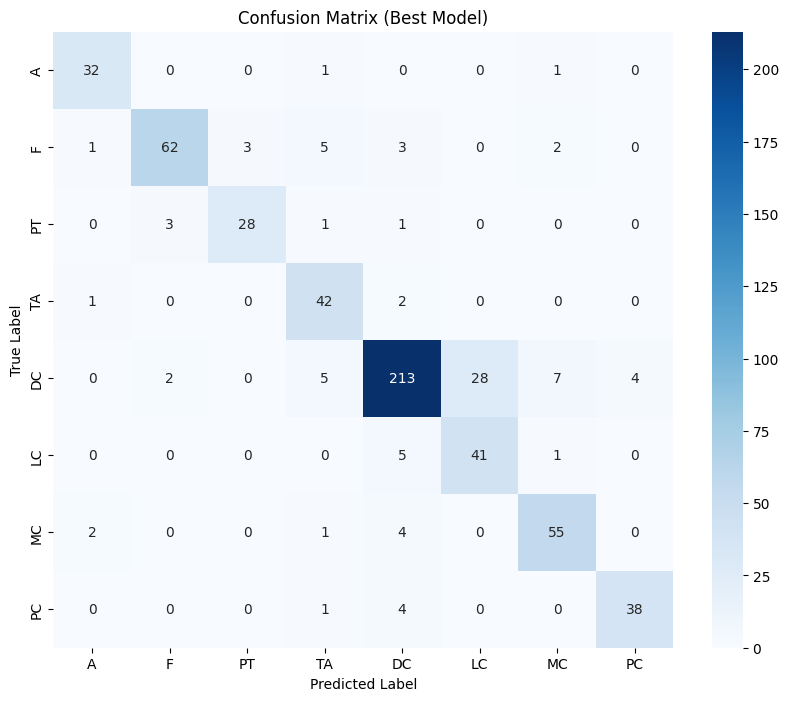

In [13]:
print("Generating Confusion Matrix on Validation Set...")
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y.numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=full_dataset.classes, 
            yticklabels=full_dataset.classes)
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

There is a slight fail around classes DC-LC. Model falsely classifies some DC as LC class. But its okay because DC is already biggest class so false positives will happen.

In [31]:
def calculate_metrics(matrix):
    num_classes = matrix.shape[0]
    metrics = {}

    for i in range(num_classes):
        tp = matrix[i, i]
        fp = matrix[:, i].sum() - tp
        fn = matrix[i, :].sum() - tp
        
        # Precision & Recall
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        # F1-Score
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        
        metrics[f"Class {i}"] = {
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1": round(f1, 4),
        }

    macro_f1 = np.mean([m["F1"] for m in metrics.values()])
    
    return metrics, macro_f1

# Execute
results, m_f1= calculate_metrics(cm)

# Display Results + additional metrics
supports = cm.sum(axis=1)
total = cm.sum()
overall_acc = np.trace(cm) / total if total > 0 else 0.0

# Add per-class support and specificity
specificities = []
for i in range(cm.shape[0]):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = total - (tp + fp + fn)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    specificities.append(specificity)

    results[f"Class {i}"]["Specificity"] = round(specificity, 4)
    results[f"Class {i}"]["Support"] = int(supports[i])

# Macro / weighted aggregates
macro_precision = np.mean([v["Precision"] for v in results.values()])
macro_recall = np.mean([v["Recall"] for v in results.values()])
macro_specificity = np.mean(specificities)
balanced_accuracy = (macro_recall + macro_specificity) / 2

weighted_f1 = np.average([v["F1"] for v in results.values()], weights=supports)

cls_mapping = {i: cls for i, cls in enumerate(full_dataset.classes)}
results = {cls_mapping[int(k.split()[1])]: v for k, v in results.items()}

print(f"Overall Accuracy: {overall_acc:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Specificity: {macro_specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
for cls, m in results.items():
    print(f"{cls} -> F1: {m['F1']}")


Overall Accuracy: 0.8531
Macro Precision: 0.8397
Macro Recall: 0.8755
Specificity: 0.9773
Balanced Accuracy: 0.9264
Weighted F1-Score: 0.8563
A -> F1: 0.9143
F -> F1: 0.8671
PT -> F1: 0.875
TA -> F1: 0.8317
DC -> F1: 0.8676
LC -> F1: 0.7069
MC -> F1: 0.8594
PC -> F1: 0.8941
